# Celdas exclusvias para levantar el notebook en colab

In [2]:
!git clone -b prod  https://github.com/SantiagoGalan/CROP_1

Cloning into 'CROP_1'...
remote: Enumerating objects: 2307, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 2307 (delta 25), reused 70 (delta 21), pack-reused 2216 (from 2)
Receiving objects: 100% (2307/2307), 478.56 MiB | 28.12 MiB/s, done.
Resolving deltas: 100% (900/900), done.


In [3]:
%cd CROP_1/project/

/content/CROP_1/project


# Entrenamiento de modelos

Usando fashion como dataset
Epoch 1/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 4.3492 - loss: 43.8848 - reconstruction_loss: 39.5451 - val_kl_loss: 3.5437 - val_loss: 30.5827 - val_reconstruction_loss: 27.1339
Epoch 2/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.4495 - loss: 28.7355 - reconstruction_loss: 25.2865 - val_kl_loss: 3.4191 - val_loss: 27.8184 - val_reconstruction_loss: 24.4665
Epoch 3/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.3481 - loss: 27.1116 - reconstruction_loss: 23.7633 - val_kl_loss: 3.3725 - val_loss: 26.9170 - val_reconstruction_loss: 23.6196
Epoch 4/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.2760 - loss: 26.3516 - reconstruction_loss: 23.0756 - val_kl_loss: 3.1743 - val_loss: 26.3668 - val_reconstruction_loss: 23.2816
Epoch 5/10
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.2370 - loss: 25.8555 - reconstruction_loss: 22.6185 - val_kl_loss: 2.9805 - val_loss: 25.9173 - val_reconstruction_loss: 22.9957
Ep

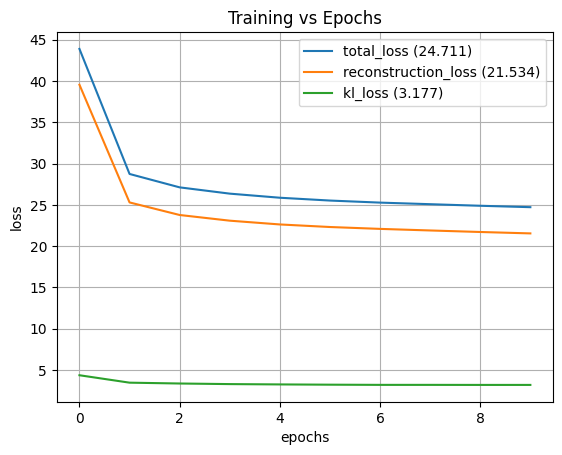

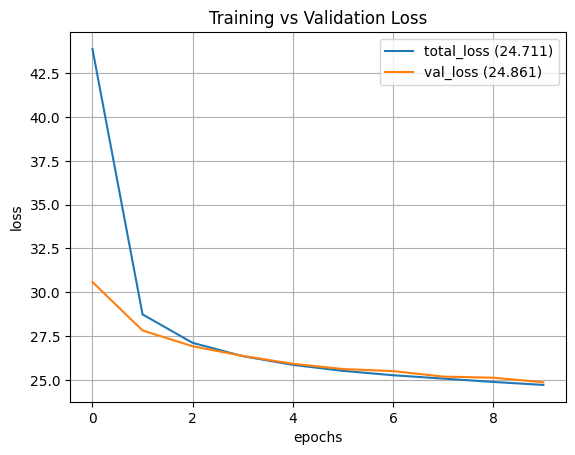

In [5]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
ORIGINAL_DIM = 784
DATASET = "fashion" # puede ser "mnist" o "fashion"
BETA = 1.0
EPOCHS= 10

# se pueden entrenar varios modelos si se descomentan
# se pueden agregar los modelos que se quieran si se agregan con el formato de diccionario

MODEL_TO_TRAIN = [
    {"inter": 128, "lat": 2},
#    {"inter": 128, "lat": 64},
#    {"inter": 256, "lat": 64},
#    {"inter": 256, "lat": 128},
#    {"inter": 512, "lat": 128},
#    {"inter": 512, "lat": 256},
#    {"inter": 784, "lat": 784},
]

## parametros
data = Loader.data(dataset=DATASET)
'''
data es un diccionario que tiene las siguientes claves:
- x_train, y_train: Datos de entrenamiento
- x_train_1, y_train_1: Datos de entrenamiento permutados
- x_val, y_val: Datos de validación
- x_test, y_test: Datos de prueba
- x_test, y_test: Datos de prueba permutados
- labels : Nombres de las clases (Números en el el caso de MNIST o
                                  nombre de las prendas de ropas para Fashion )
'''

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

for model in MODEL_TO_TRAIN:

    inter = model["inter"]
    lat = model["lat"]

    en = Encoder(
        intermediate_dim=inter,
        latent_dim=lat,
    )
    de = Decoder(
        intermediate_dim=inter,
        latent_dim=lat,
    )
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=ORIGINAL_DIM,
        beta=BETA,
    )

    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)

    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()

    #configuracion del EarlyStopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=val_dataset,
        callbacks=[early_stopping],
        verbose=1
    )

    #en.save(f"en_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras") # descomentar para guardar
    #de.save(f"de_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}.keras") # descomentar para guardar

    loss_val = round(history.history["loss"][-1], 3)
    recon_val = round(history.history["reconstruction_loss"][-1], 3)
    kl_val = round(history.history["kl_loss"][-1], 3)

    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["reconstruction_loss"], label=f"reconstruction_loss ({recon_val})")
    plt.plot(history.history["kl_loss"], label=f"kl_loss ({kl_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Epochs")
    plt.legend()
    #plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}") # descomentar para guardar
    plt.show()
    loss_val = round(history.history["loss"][-1], 3)
    val_loss_val = round(history.history["val_loss"][-1], 3)

    plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    plt.plot(history.history["val_loss"], label=f"val_loss ({val_loss_val})")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Validation Loss")
    plt.legend()
    #plt.savefig(f"training_loss_vs_val_loss_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}") # descomentar para guardar
    plt.show()


## Entrenamiento del clasificador

Usando mnist como dataset
Epoch 1/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.3189 - val_loss: 0.1966
Epoch 2/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1119 - val_loss: 0.0758
Epoch 3/3
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0842 - val_loss: 0.0543


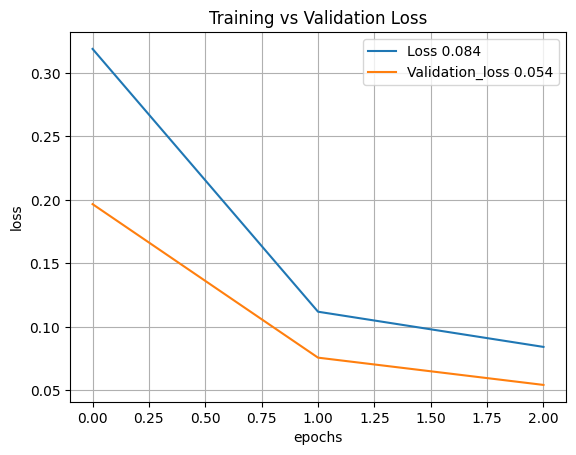

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Predictor
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
DATASET = "mnist" # mnist o fashion
EPOCHS = 20

## parametros
data = Loader.data(dataset=DATASET)

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

predictor = Predictor()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

loss = round(history.history["loss"][-1], 3)
loss_val = round(history.history["val_loss"][-1], 3)

#predictor.save("early_stop_fashion.keras") #descomentar para guardar
plt.plot(history.history["loss"], label=f"Loss {loss}" )
plt.plot(history.history["val_loss"], label=f"Validation_loss {loss_val}" )
plt.title("Training vs Validation Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}") #descomentar para guardar
plt.show()

# Carga de modelos

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Datos de configuración. Para Cargar un CVAE se necesitan estas 3 variables:
DATASET="mnist" # mnist o fashion
LAT=2 # Ver los modelos ya entrenados o entrenar previamente un modelo.
INTER=128 # Ver los modelos ya entrenados o entrenar previamente un modelo.

#Cargar un solo auto-enconder
cvae_model = Loader.cvae(lat=LAT,inter=INTER,dataset=DATASET)


#Cargar todos los CVAE disponibles
models = Loader.all_cvaes(dataset=DATASET)

#cargar un predictor
predictor = Loader.predictor(dataset=DATASET)




# Pruebas de CVAE

## Espacio latente

Usando fashion como dataset


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


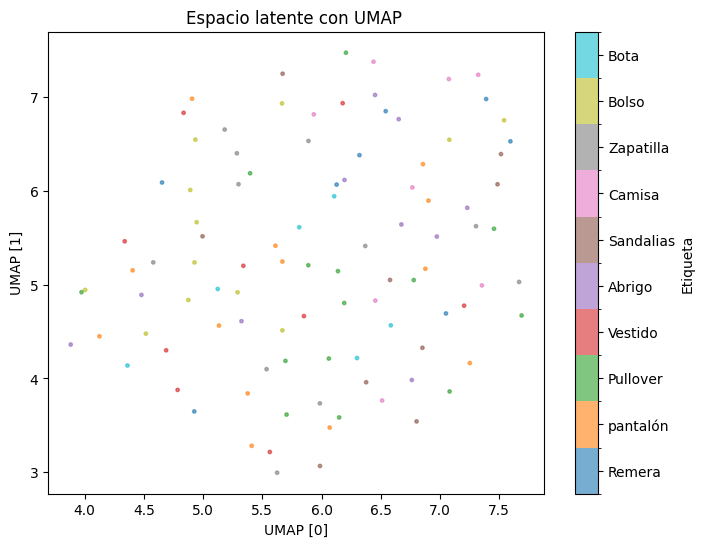

In [3]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader

import project.visualizations.visualizations as vis
import tensorflow as tf

DATASET="fashion" # mnist o fashion
N_POINTS=100 # Cantidad de puntos a visualizar


#Puede ser cualquiera de los modelos entrenados
cvae = Loader.cvae(lat=64, inter=128, dataset=DATASET)

data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)


x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]

test_dataset = tf.data.Dataset.from_tensor_slices(((x_test, y_test), x_test))


vis.latent_space_umap(cvae, test_dataset, n_points=N_POINTS,label_names=labels, title= cvae.name)





## Error de reconstrucción

Usando mnist como dataset
cvae_int_128_lat_64
cvae_int_256_lat_64
cvae_int_512_lat_256
cvae_int_128_lat_2
cvae_int_784_lat_784
cvae_int_512_lat_128
cvae_int_256_lat_128


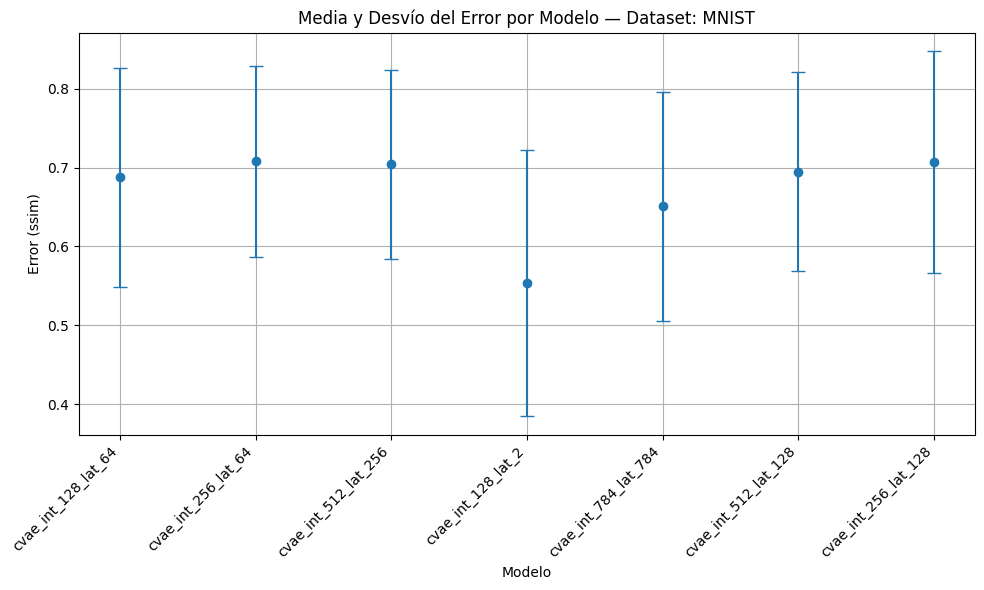

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

DATASET = "mnist" # mnist o fashion
METRIC = "ssim" # ssim o psnr
N_PICTURES = 100
N_PIXELS=28

data = Loader.data(dataset=DATASET)

models = Loader.all_cvaes(dataset=DATASET) #Guardan todos los modelos en este caso.
                                           #Pude armarse un vector de los modelos a analizar

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
errores = []

for m in models:

    #print(m.name)

    errores_modelo = []

    for i in range(N_PICTURES):
        x = x_test[i : i + 1]  # (1, 28, 28)
        y = y_test[i: i + 1]  # (1, 10)

        z_mean, _, z = m.encoder.predict([x, y], verbose=0)

        x_recon = m.decoder.predict([z, y], verbose=0)

        # Calcular error
        if METRIC == "psnr":
             error_value = Metrics.psnr_grayscale(target=x, preds=x_recon)
        elif METRIC=="ssim":
            error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)

        errores_modelo.append(error_value)

    errores.append(errores_modelo)

    x_pic = tf.reshape(x, (N_PIXELS, N_PIXELS))
    x_recon = tf.reshape(x_recon, (N_PIXELS, N_PIXELS))

errores_np = np.array(errores)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

model_names = [m.name.replace(f"_{DATASET}.keras", "") for m in models]

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {DATASET.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Error ({METRIC})")
plt.grid(True)

# Usar nombres como ticks
plt.xticks(x, model_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()




## Reconstrución de un imagen para cada modelo

Usando mnist como dataset


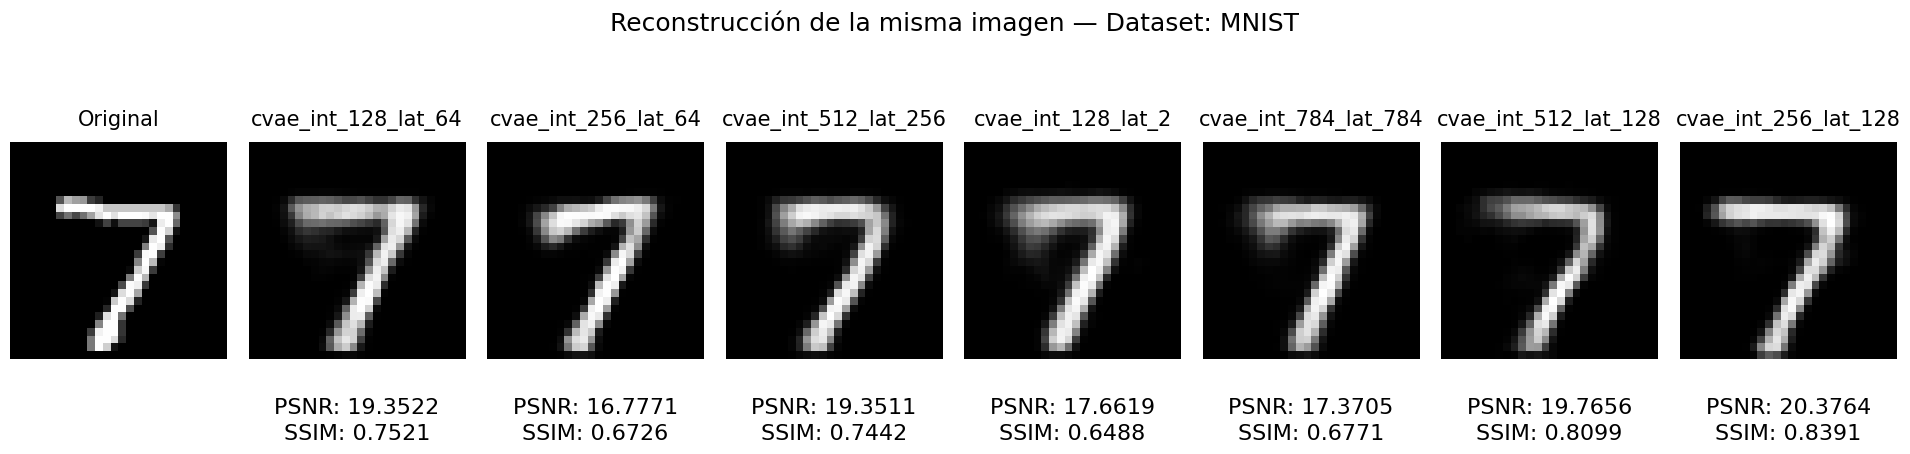

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics
import matplotlib.pyplot as plt

DATASET = "mnist" # mnist o fashion
data = Loader.data(dataset=DATASET)
models = Loader.all_cvaes(dataset=DATASET)
IDX_IMG = 0

x_test = data["x_test"]
y_test = data["y_test"]

#Configuración
x = x_test[IDX_IMG:IDX_IMG+1]   # (1, 28, 28)
y = y_test[IDX_IMG: IDX_IMG+1]   # (1, 10)

n_models = len(models)

#Crear figura
fig, axes = plt.subplots(1, len(models) + 1,
                         figsize=(2.6*len(models)+1, 4.8))
plt.subplots_adjust(top=0.75)

# Imagen original
axes[0].imshow(x.reshape(28, 28), cmap="gray")
axes[0].set_title("Original", pad=12, fontsize=15)
axes[0].axis("off")

for i, m in enumerate(models):

    z_mean, _, z = m.encoder.predict([x, y], verbose=0)
    x_recon = m.decoder.predict([z, y], verbose=0)

    # -------- Calcular métricas --------
    psnr_value = float(
        Metrics.psnr_grayscale(target=x, preds=x_recon)
    )
    ssim_value = float(
        Metrics.ssim_grayscale(target=x, preds=x_recon)
    )

    ax = axes[i + 1]
    ax.imshow(x_recon.reshape(28, 28), cmap="gray")

    model_name = m.name.replace(f"_{DATASET}.keras", "")

    # Nombre del modelo arriba
    ax.set_title(model_name, pad=12, fontsize=15)

    # -------- Métricas abajo --------
    ax.text(
        0.5, -0.18,
        f"PSNR: {psnr_value:.4f}",
        ha="center",
        va="top",
        transform=ax.transAxes,
        fontsize=16
    )

    ax.text(
        0.5, -0.30,
        f"SSIM: {ssim_value:.4f}",
        ha="center",
        va="top",
        transform=ax.transAxes,
        fontsize=16
    )

    ax.axis("off")

plt.suptitle(
    f"Reconstrucción de la misma imagen — Dataset: {DATASET.upper()}",
    fontsize=18,
    y=0.95
)

plt.tight_layout(rect=[0, 0.08, 1, 0.9])
plt.show()


## Error de reconstrucción por clase

Usando fashion como dataset


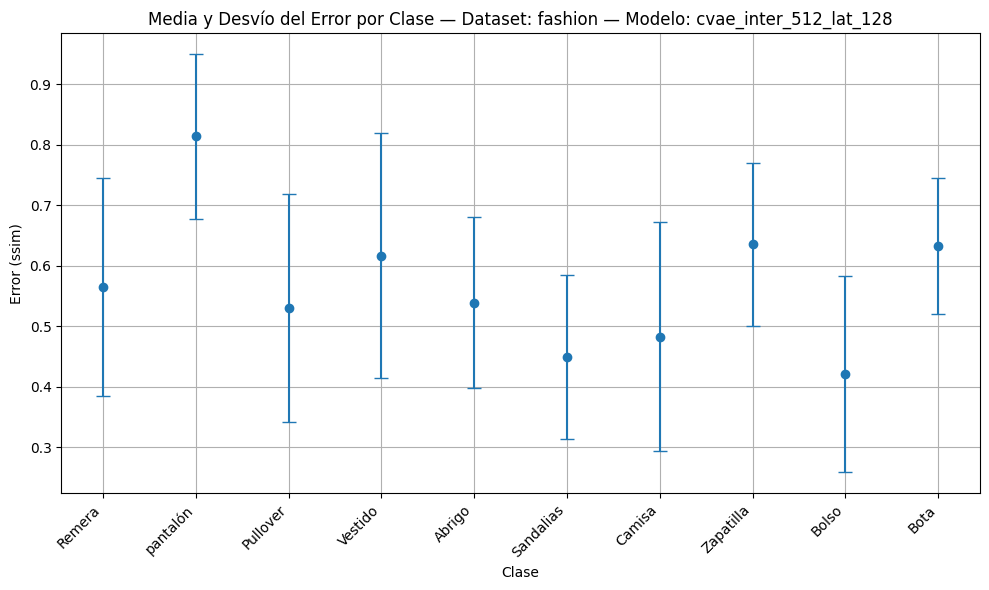

In [9]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.metrics.metrics import Metrics
import numpy as np
import matplotlib.pyplot as plt

DATASET = "fashion" # mnist o fashion
METRIC = "ssim" # ssim o pnsr
N_PICTURES = 1000

INTER = 512 # Ver modelos ya entrenados
LAT=128

def estadisticas_por_clase(errores_modelo, num_clases=10):

    agrupados = {c: [] for c in range(num_clases)}
    for c, e in errores_modelo:
        agrupados[c].append(e)

    means = np.array([np.mean(agrupados[c]) for c in range(num_clases)])
    stds  = np.array([np.std(agrupados[c]) for c in range(num_clases)])
    return means, stds



data = Loader.data(dataset=DATASET)


model = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
x_test = data["x_test"]
y_test = data["y_test"]
labels = data["labels"]
resultados = []
errores = []

errores_modelo = []

for idx in range(N_PICTURES):
    x = x_test[idx : idx + 1]
    y = y_test[idx : idx + 1]

    z_mean, _, z = model.encoder.predict([x, y], verbose=0)

    x_recon = model.decoder.predict([z, y], verbose=0)

    clase = int(np.argmax(y))
    if METRIC == "ssim":
        error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)
    elif METRIC == "psnr":
        error_value = Metrics.psnr_grayscale(target=x, preds=x_recon)
    else:    
        raise ValueError(f"metric debe ser psnr o ssim. se recivio {METRIC} ")

    errores_modelo.append((clase, error_value))

errores.append(errores_modelo)


modelo_idx = 0
errores_modelo = errores[modelo_idx]

means, stds = estadisticas_por_clase(errores_modelo)

clases = np.arange(len(means))


plt.figure(figsize=(10, 6))
plt.errorbar(clases, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Clase — Dataset: {DATASET} — Modelo: cvae_inter_{INTER}_lat_{LAT}")
plt.xlabel("Clase")
plt.ylabel(f"Error ({METRIC})")
plt.grid(True)

plt.xticks(clases, labels, rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("ssim_reconstruccion_por_clase_mnist_inter_512_lat_128")
plt.show()


# CROP

## Curvas de acc

Usando mnist como dataset


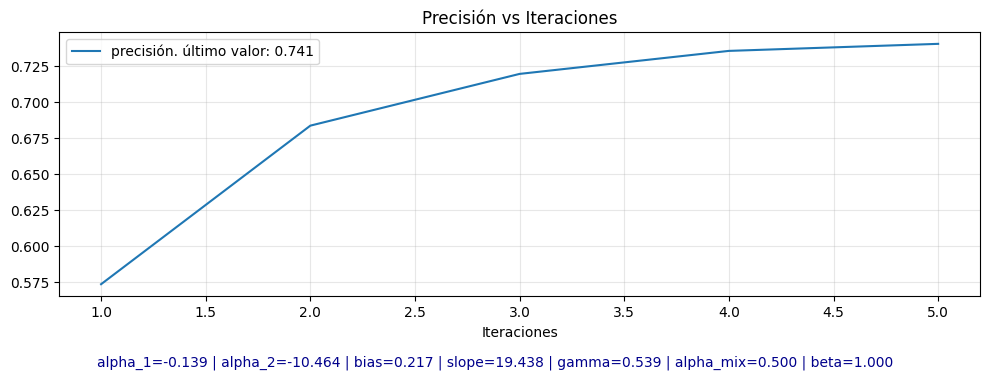


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.997  std:2.492
mask_bpsnr       : mean: 11.540  std:1.906
ssim             : mean: 0.710  std:0.107
acc_at_least_one : 0.976
acc_both         : 0.741



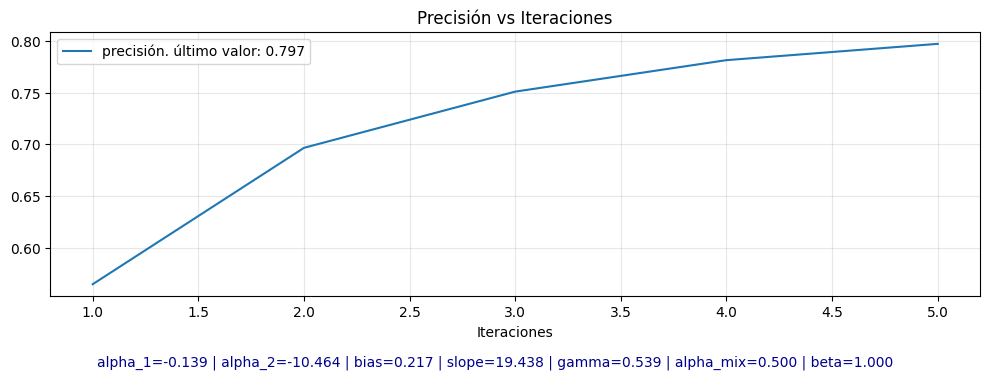


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.222  std:3.012
mask_bpsnr       : mean: 13.197  std:1.923
ssim             : mean: 0.760  std:0.113
acc_at_least_one : 0.978
acc_both         : 0.797



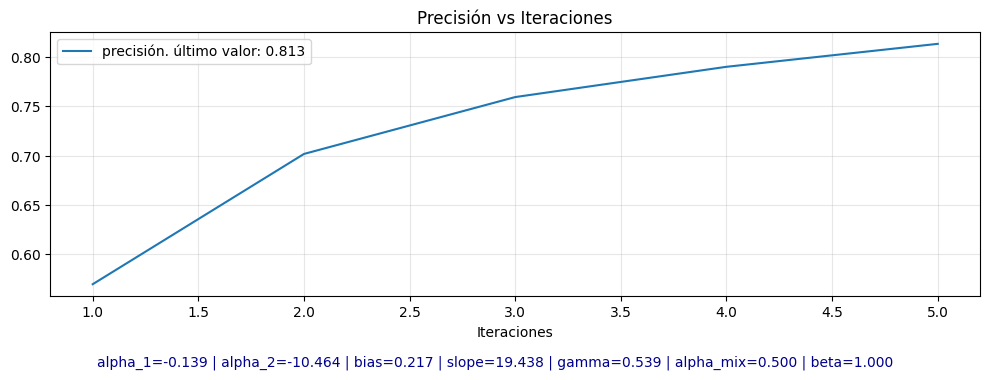


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.494  std:3.049
mask_bpsnr       : mean: 13.504  std:1.976
ssim             : mean: 0.770  std:0.111
acc_at_least_one : 0.980
acc_both         : 0.813



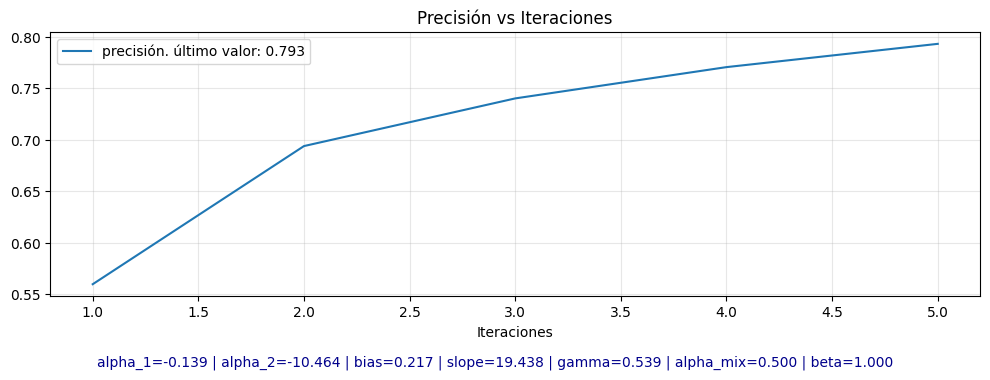


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.303  std:3.177
mask_bpsnr       : mean: 13.360  std:2.074
ssim             : mean: 0.761  std:0.118
acc_at_least_one : 0.976
acc_both         : 0.793



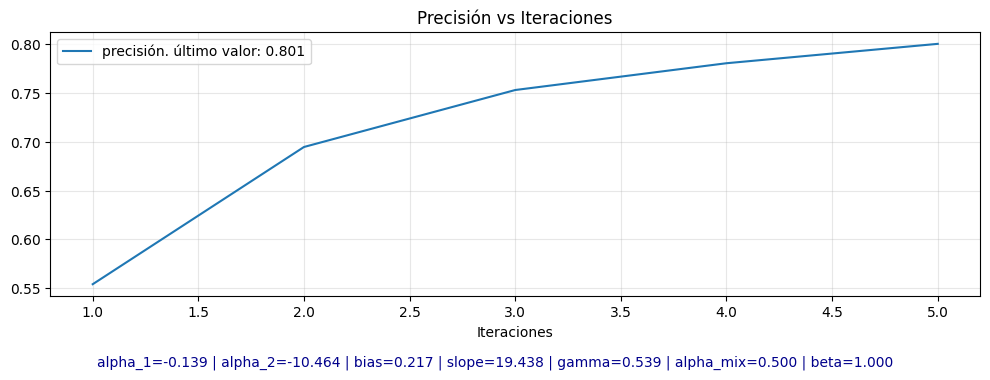


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.410  std:3.136
mask_bpsnr       : mean: 13.255  std:2.004
ssim             : mean: 0.767  std:0.115
acc_at_least_one : 0.977
acc_both         : 0.801



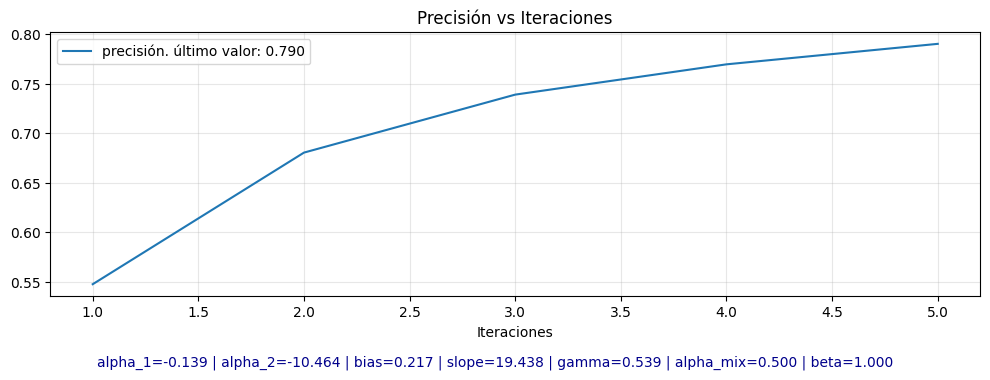


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.247  std:3.140
mask_bpsnr       : mean: 13.334  std:2.082
ssim             : mean: 0.759  std:0.119
acc_at_least_one : 0.976
acc_both         : 0.790



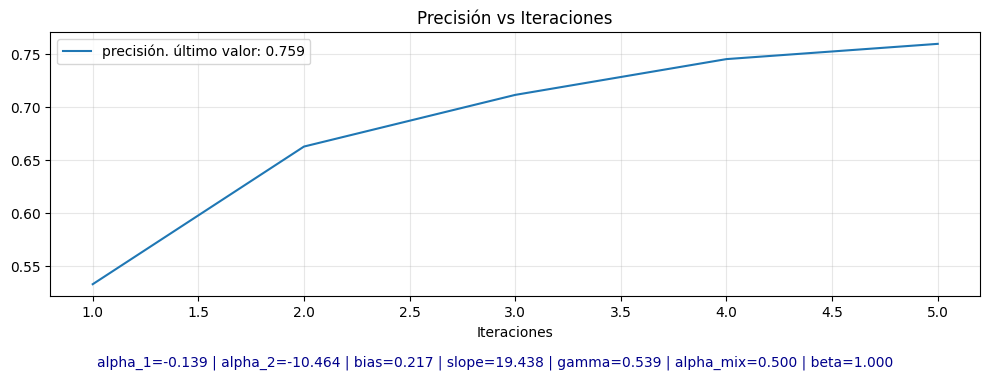


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 0.539
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 17.807  std:2.943
mask_bpsnr       : mean: 12.756  std:1.967
ssim             : mean: 0.738  std:0.118
acc_at_least_one : 0.970
acc_both         : 0.759



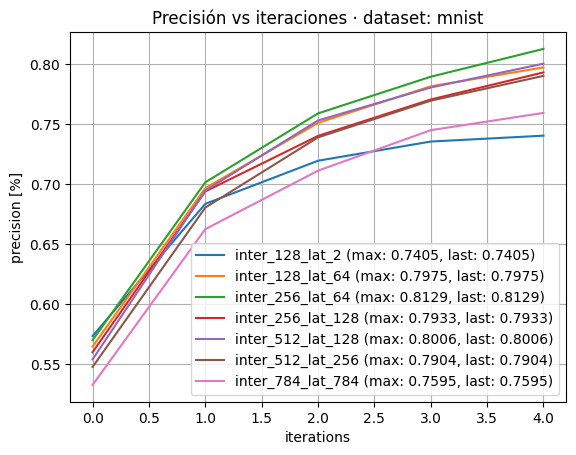

In [3]:
#codigo de curvas
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.CROP.models.crop2 import Crop2


'''
Aclaración sobre los parámetros
CROP usa los siguiente parametros:
bias, slope, alpha_1, alpha_2 gamma y beta.
Si no se especifica nada, se usan los valores por defecto.
Para usar parametros distintos, hay que pasarlos como un diccionaio (Ver MNIST_PARAMS)
'''

# config
DATASET = "mnist" # mnist o fashion
ITERATIONS = 5


MNIST_PARAMS = {
    'bias': 0.21716868437244724,
    'slope': 19.437646607877017,
    'alpha_1': -0.13863158439804657,
    'alpha_2': -10.463749682840565,
    'gamma': 0.5392507616026618
}


MODELS = [ # Modelos usados para comparar
    {"inter": 128, "lat": 2},
    {"inter": 128, "lat": 64},
    {"inter": 256, "lat": 64},
   {"inter": 256, "lat": 128},
   {"inter": 512, "lat": 128},
   {"inter": 512, "lat": 256},
   {"inter": 784, "lat": 784},
]


#Data & predictor
data = Loader.data(dataset=DATASET)
predictor = Loader.predictor(dataset=DATASET)

x_test, x_test_1 = data["x_test"], data["x_test_1"]
y_test, y_test_1 = data["y_test"], data["y_test_1"]


# Evaluation
results = {}

for model in MODELS:

    inter = model["inter"]
    lat = model["lat"]

    #cvae = Loader.cvae(lat=lat, inter=inter, dataset=DATASET)
    crop = Crop2(predictor=predictor, lat=lat,inter=inter,dataset=DATASET)

    metrics = crop.unmix( #Crop tiene un metodo para hacer esta curva de acc
        x_test, # primer conjunto de datos
        x_test_1, # Segundo conjunto de datos para mezclar
        y_test, # labels del primer conjunto
        y_test_1, # labels del segundo conjunto
        iterations=ITERATIONS,
        show_acc_curve=True,
        params=MNIST_PARAMS
    #     {
    # 'bias': 0.21716868437244724,
    # 'slope': 19.437646607877017,
    # 'alpha_1': -0.13863158439804657,
    # 'alpha_2': -10.463749682840565,
    # 'gamma': 1.53}
    # 
    )

    results[(lat, inter)] = metrics


# -------------------- plot --------------------
for (lat, inter), m in results.items():
    acc = m["acc_both_plot"]
    plt.plot(
        acc,
        label=f"inter_{inter}_lat_{lat} "
              f"(max: {np.max(acc):.4f}, last: {acc[-1]:.4f})"
    )

plt.grid()
plt.title(f"Precisión vs iteraciones · dataset: {DATASET}")
plt.xlabel("iterations")
plt.ylabel("precision [%]")
plt.legend()
#plt.savefig(f"acc_both_classes_models_{DATASET}.png")
plt.show()


## Sepración de dígitos

Usando fashion como dataset


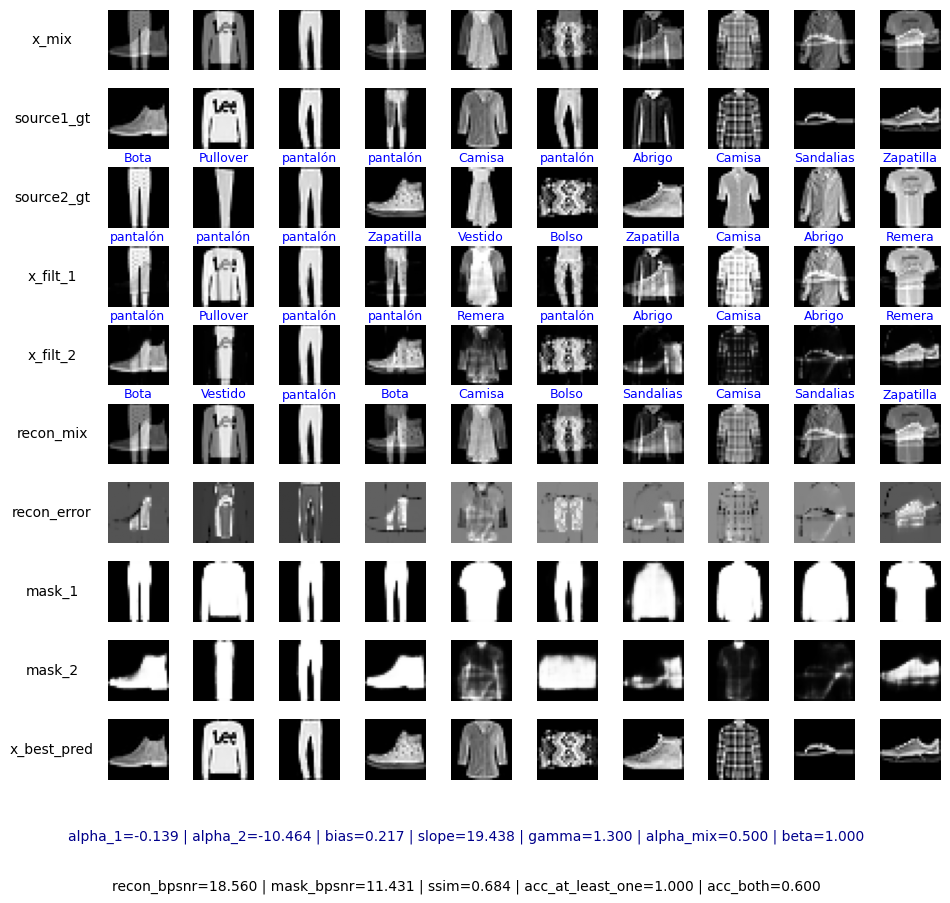


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 1.300
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.560  std:4.331
mask_bpsnr       : mean: 11.431  std:1.937
ssim             : mean: 0.684  std:0.196
acc_at_least_one : 1.000
acc_both         : 0.600



In [18]:
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.CROP.models.crop2 import Crop2

SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 15
N_PICTURES = 10

DATASET = "fashion" # minst o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

c = Crop2(cvae=cvae,predictor=predictor)

acc_both_params={'bias': 0.21716868437244724,
'slope': 19.437646607877017,
 'alpha_1': -0.13863158439804657,
  'alpha_2': -10.463749682840565,
  'gamma': 1.3}
 # 'gamma': 0.5392507616026618}


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=True,
    labels=labels,
    params=acc_both_params
)




## Optimización de parametros

In [ ]:
# hay que instalar esta libreria para correr la siguiente celda.
!pip install optuna

In [ ]:
#optim + sepración
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop3 import Crop3

dataset = "fashion"

lat=64
inter=256
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop2(predictor=predictor,lat=lat,inter=inter,dataset=dataset)

def objective(trial):
#
    #bias = trial.suggest_float("bias", 0.05,0.30)
    #slope = trial.suggest_float("slope", 5,20 )
    #gamma = trial.suggest_float("gamma", 0.1, 0.45)
    #alpha_1= trial.suggest_float("alpha_1", -0.3, -0.05)
    #alpha_2= trial.suggest_float("alpha_2", -30, -5)
# beta = trial.suggest_float("beta",0,1.5)
#####
    bias_e = trial.suggest_float("bias", -1,10)
    slope_e = trial.suggest_float("slope", -0.1,25 )
    gamma = trial.suggest_float("gamma", 0,3 )
    
    n_images=2000
    try:
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={'bias': 0.21716868437244724,
            'slope': 19.437646607877017,
            'alpha_1': -0.13863158439804657,
            'alpha_2': -10.463749682840565,
            "gamma": gamma,
            "bias_e":bias_e,
            "slope_e":slope_e},                
            iterations=10,
            show_metrics=False
        )
        met = float(metrics["ssim"][0])
        return  met

    except Exception as e:
        print(f"Error con gamma={gamma}: {e}")
        return float("inf")


import optuna


study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=100)

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials[0].params)

#{'gamma': 1.378449424990954} psnr 
#'gamma': 0.11498749766563751

Usando fashion como dataset


[I 2026-04-21 19:57:21,063] A new study created in memory with name: no-name-a8689b34-3d9a-4e02-a41a-0eedb8b63b79
[I 2026-04-21 19:57:23,619] Trial 0 finished with value: 0.3999159038066864 and parameters: {'gamma': 0.10398984194324778}. Best is trial 0 with value: 0.3999159038066864.
[I 2026-04-21 19:57:26,466] Trial 1 finished with value: 0.39628076553344727 and parameters: {'gamma': 0.4096558019050503}. Best is trial 0 with value: 0.3999159038066864.
[I 2026-04-21 19:57:29,278] Trial 2 finished with value: 0.37076622247695923 and parameters: {'gamma': 1.8013508500042594}. Best is trial 0 with value: 0.3999159038066864.
[I 2026-04-21 19:57:31,920] Trial 3 finished with value: 0.2714877128601074 and parameters: {'gamma': 2.204745607164676}. Best is trial 0 with value: 0.3999159038066864.
[I 2026-04-21 19:57:34,386] Trial 4 finished with value: 0.3988000452518463 and parameters: {'gamma': 0.26718891504067366}. Best is trial 0 with value: 0.3999159038066864.
[I 2026-04-21 19:57:37,010] 


📊 Mejores hiperparámetros encontrados:
{'gamma': 0.11498749766563751}


# Algunos extras

## Variaciones de un una imagen a lo largo del espacio latente.

2026-02-09 10:00:04.299442: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 10:00:04.300071: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 10:00:04.303303: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 10:00:04.310199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770642004.321974 1679287 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770642004.32

Usando fashion como dataset


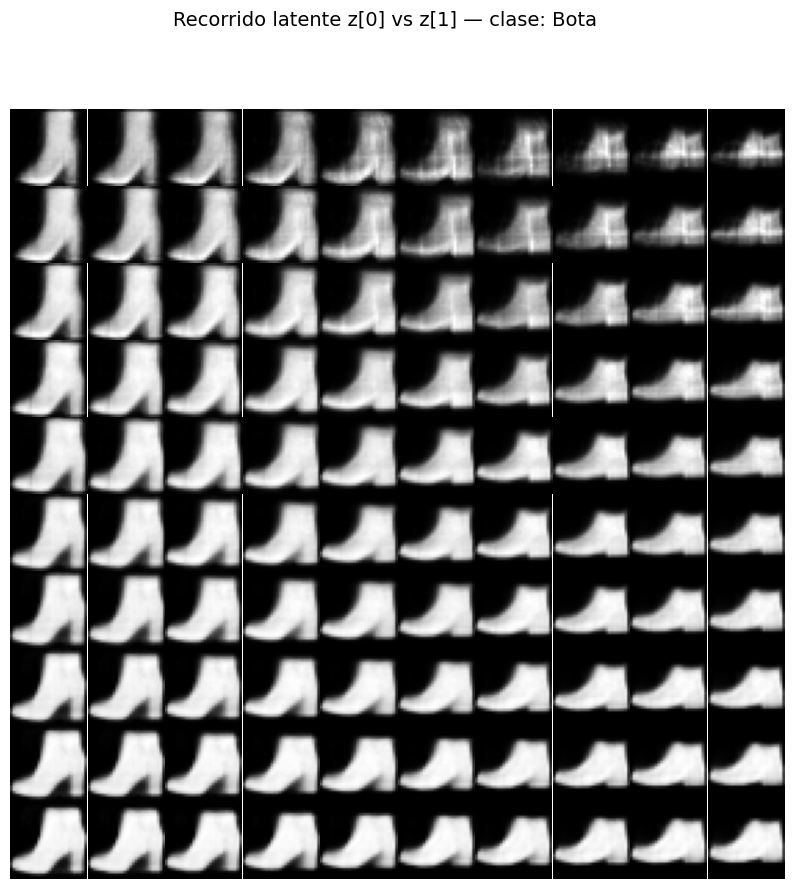

In [ ]:
import numpy as np
#optim + sepración
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))


from project.loader import Loader
from project.CROP.models.crop2 import Crop2

dataset = "fashion"

def recorrer_latente_2d(
    cvae,
    x_input,
    condicion_id,
    labels,
    idx1=0,
    idx2=1,
    sides=8,
    max_z=1.5
):
    import numpy as np
    import matplotlib.pyplot as plt

    x_input = np.expand_dims(x_input, axis=0)
    condicion = np.eye(10)[condicion_id].reshape(1, -1)

    z_mean, _, _ = cvae.encoder.predict([x_input, condicion], verbose=0)

    grid = np.linspace(-max_z, max_z, sides)
    fig = plt.figure(figsize=(sides, sides))

    img_it = 0
    for i, z1 in enumerate(grid):
        for j, z2 in enumerate(grid):
            z = z_mean.copy()
            z[0, idx1] = z1
            z[0, idx2] = z2

            decoded = cvae.decoder.predict(
                [z, condicion],
                verbose=0
            )

            plt.subplot(sides, sides, img_it + 1)
            plt.imshow(decoded[0].reshape(28, 28), cmap="gray")
            plt.axis("off")
            img_it += 1

    plt.suptitle(
        f"Recorrido latente z[{idx1}] vs z[{idx2}] — clase: {labels[condicion_id]}",
        fontsize=14
    )
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


cvae = Loader.cvae(lat=2,inter=128,dataset=dataset)
dataset_info = Loader.data(dataset=dataset)
x_test = dataset_info["x_test"]
y_test = dataset_info["y_test"]
labels = dataset_info["labels"]
recorrer_latente_2d(
    cvae,
    x_input=x_test[0],     # shape (28, 28)
    condicion_id=np.argmax(y_test[0]),
    idx1=0,
    idx2=1,
    labels=labels,
    sides=10,
    max_z=2
)

In [10]:
pip install numpy matplotlib scikit-image tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 31.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
